In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder # don't use OHE for neural networks (creates separate columns)

import mlflow
import mlflow.pytorch
import mlflow.pyfunc
from mlflow.models.signature import infer_signature

### Data Pre-processing

In [2]:
# Already have separate training and testing sets -- no need for train-test split
train_data = pd.read_csv("Training.csv")
test_data = pd.read_csv("Testing.csv")

In [3]:
train_data.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [4]:
X_train = train_data.drop(columns=['prognosis','Unnamed: 133']).values  # Feature matrix
y_train = train_data['prognosis'].values

X_test = test_data.drop(columns=['prognosis']).values  # Feature matrix
y_test = test_data['prognosis'].values

In [5]:
type(y_train)

numpy.ndarray

In [6]:
np.unique(y_train) # Have to encode the disease values in this

array(['(vertigo) Paroymsal  Positional Vertigo', 'AIDS', 'Acne',
       'Alcoholic hepatitis', 'Allergy', 'Arthritis', 'Bronchial Asthma',
       'Cervical spondylosis', 'Chicken pox', 'Chronic cholestasis',
       'Common Cold', 'Dengue', 'Diabetes ',
       'Dimorphic hemmorhoids(piles)', 'Drug Reaction',
       'Fungal infection', 'GERD', 'Gastroenteritis', 'Heart attack',
       'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E',
       'Hypertension ', 'Hyperthyroidism', 'Hypoglycemia',
       'Hypothyroidism', 'Impetigo', 'Jaundice', 'Malaria', 'Migraine',
       'Osteoarthristis', 'Paralysis (brain hemorrhage)',
       'Peptic ulcer diseae', 'Pneumonia', 'Psoriasis', 'Tuberculosis',
       'Typhoid', 'Urinary tract infection', 'Varicose veins',
       'hepatitis A'], dtype=object)

In [7]:
# Encode disease names in target feature
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)  # Convert to integer labels
y_test_encoded = label_encoder.transform(y_test)

In [8]:
np.unique(y_train_encoded)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40])

In [9]:
# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long) # target labels must be in long format
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

### Build Neural Network

In [10]:
input_size = X_train.shape[1]                 # number of features
num_classes = len(label_encoder.classes_)     # number of unique diseases

# Build neural network for multi-class classification -----

class DiseaseClassifier(nn.Module): # Define the layers and functions
    def __init__(self, input_size, num_classes):        # takes two inputs: input_size (number of features) & num_classes (number of possible disease categories)
        super(DiseaseClassifier, self).__init__()       # for regression, don't add num_classes

        self.fc1 = nn.Linear(input_size, 64)            # 1st hidden layer: input size -> 64 neurons; 1 neuron per feature (symptom) to just 64
        self.fc2 = nn.Linear(64, 32)                    # 2nd hidden layer: 64 -> 32; passess 64 inputs from prev. layer into 32 to extract deeper insights
        self.fc3 = nn.Linear(32, num_classes)           # Output layer: 32 -> number of classes (one neuron per class); maps outputted logits to each class (would just map to 1 for regression)
        self.relu = nn.ReLU()                           # ReLU: activation function; zeroes out negative weights, helps model learn complex patterns in the data
        self.dropout = nn.Dropout(0.3)                  # Dropout: randomly turns off 30% of neurons during training to prevent overfitting

    def forward(self, x): # Define the order 
        x = self.relu(self.fc1(x))                      # apply 1st hidden layer, then ReLU activation
        x = self.dropout(x)                             # randomly drop 30% of neurons for better generalization
        x = self.relu(self.fc2(x))                      # apply 2nd hidden layer, then ReLU activation for that as well
        x = self.fc3(x)                                 # apply final layer; outputs raw scores (logits) for each disease
        
        return x                                        # no softmax activation here because CrossEntropyLoss() automatically applies it

Larger layers capture complex patterns

Too large = Overfitting; Too small = Underfitting

Always start with input size and gradually reduce it; too fast results in losing important information

Use multiples of 8 for neuron count for better GPU performance (more memory efficiency)

In [11]:
# Initialize model, loss function, and optimizer -----
model = DiseaseClassifier(input_size, num_classes)
criterion = nn.CrossEntropyLoss()                          # define multi-class classification loss (for regression, use MSELoss())
optimizer = optim.Adam(model.parameters(), lr=0.001)       # define Adam optimizer to update weights with learning rate (step size)


# Training loop -----
num_epochs = 500
losses = [] # for storing losses

for epoch in range(num_epochs): # Trains the model 500 times (according to num_epochs)
    model.train()                                 # set model to training mode
    outputs = model(X_train_tensor)               # feeds training data into model, gets predicted outputs (logits)
    loss = criterion(outputs, y_train_tensor)     # uses loss function from CrossEntropyLoss() to compare

    optimizer.zero_grad()                         # reset the gradients
    loss.backward()                               # compute gradients
    optimizer.step()                              # update model weights to reduce loss

    losses.append(loss.item())                    # save losses for plotting


    if (epoch + 1) % 100 == 0:  # print losses
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}")

Epoch [100/500], Train Loss: 1.1415
Epoch [200/500], Train Loss: 0.0884
Epoch [300/500], Train Loss: 0.0311
Epoch [400/500], Train Loss: 0.0173
Epoch [500/500], Train Loss: 0.0112


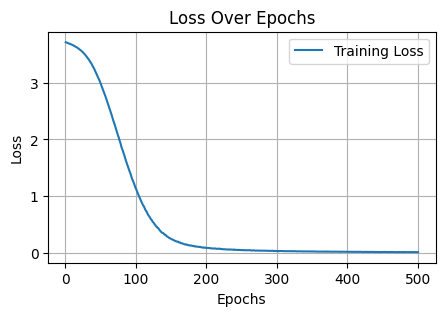

In [12]:
# Plot loss curve
plt.figure(figsize=(5,3))
plt.plot(range(1, num_epochs + 1), losses, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Over Epochs")
plt.legend()
plt.grid()
plt.show()

### Evaluate Model

In [13]:
model.eval() # sets model to evaluation mode

with torch.no_grad():                                   # tells PyTorch NOT to track gradients
    y_logits = model(X_test_tensor)                     # feeds test data into model and gets logits (confidence scores)
    y_pred_np = torch.argmax(y_logits, dim=1).numpy()   # extracts indexes (predicted class label) with highest confidence score
    y_test_np = y_test_tensor.numpy()                   # convert ground truth to numpy array for accuracy calculation


accuracy = accuracy_score(y_test_np, y_pred_np)

print(f"Test Accuracy: {accuracy*100:.3f}%")

Test Accuracy: 97.619%


In [14]:
# Convert numeric labels back to disease names
predicted_labels = label_encoder.inverse_transform(y_pred_np)
actual_labels = label_encoder.inverse_transform(y_test_np)

df_results = pd.DataFrame({    # dataframe for comparing actual vs. predicted values
    "Actual Disease": actual_labels,
    "Predicted Disease": predicted_labels
})

df_mispredict = df_results[df_results['Actual Disease'] != df_results['Predicted Disease']] # only show where there was a misprediction
df_mispredict

,Actual Disease,Predicted Disease
41,Fungal infection,Impetigo


In [ ]:
# Plot results using a confusion matrix
plt.figure(figsize=(9, 5))
sns.heatmap(pd.crosstab(df_results["Actual Disease"], df_results["Predicted Disease"]),
            annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

### MLFlow

In [24]:
mlflow.set_tracking_uri("http://127.0.0.1:1964") # Set MLflow tracking URI
mlflow.set_experiment("Disease Classification Experiment") # Create or use an existing experiment

# Define model, loss, and optimizer
model = DiseaseClassifier(input_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


params = {                                              # Hyperparameters to log
    "input_size": input_size,
    "num_classes": num_classes,
    "learning_rate": 0.001,
    "num_epochs": 500
}


# Start MLflow run
with mlflow.start_run():

    mlflow.log_params(params)                           # Log hyperparameters
    
    losses = []
    num_epochs = 500

    for epoch in range(num_epochs):
        model.train()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())                       # Store loss for logging

        if (epoch + 1) % 50 == 0:                        
            mlflow.log_metric("training_loss", loss.item(), step=epoch + 1)  # Log loss value every 50 epochs



    # Evaluate the model on test data
    model.eval()
    with torch.no_grad():
        # Test data predictions
        test_outputs = model(X_test_tensor)
        y_pred_np = torch.argmax(test_outputs, dim=1).numpy()
        y_test_np = y_test_tensor.numpy()

        # Train data predictions
        train_outputs = model(X_train_tensor)
        y_train_pred_np = torch.argmax(train_outputs, dim=1).numpy()
        y_train_np = y_train_tensor.numpy()


    # Calculate metrics
    test_accuracy = accuracy_score(y_test_np, y_pred_np)
    train_accuracy = accuracy_score(y_train_np, y_train_pred_np)
    recall = recall_score(y_test_np, y_pred_np, average="macro")  # Use macro for multi-class
    precision = precision_score(y_test_np, y_pred_np, average="macro")

    # Log metrics to MLFlow server
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("test_recall", recall)
    mlflow.log_metric("test_precision", precision)

    signature = infer_signature(X_test_tensor.numpy(), y_pred_np) # Convert to MLflow model format



    # Log and save the model to MLflow
    mlflow.pytorch.log_model(
        model,
        artifact_path="disease_model",
        signature=signature,
        registered_model_name="disease-classifier"
    )

    mlflow.set_tag("Training Info", "PyTorch Disease Classification Model")   # Set a tag for reference

Registered model 'disease-classifier' already exists. Creating a new version of this model...
2025/03/16 00:59:26 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: disease-classifier, version 6


🏃 View run rogue-mole-472 at: http://127.0.0.1:1964/#/experiments/381517450954716683/runs/071b903d7c6b490eb659d8b5f0ef6df0
🧪 View experiment at: http://127.0.0.1:1964/#/experiments/381517450954716683


Created version '6' of model 'disease-classifier'.
